# 17 — Sérsic-parameter recovery at scale

We reuse the same 5k HDF5 dataset and switch the target from the binary label to the **7-D Sérsic parameter vector**. The regressor is :class:`lensing.ml.models.SersicRegressor` (notebook 11) but trained at scale.

We measure the per-parameter recovery accuracy on a held-out split and produce a **reliability diagram**: a scatter of predicted vs. true with the 1:1 line and the 1σ scatter shaded — the standard plot in survey-scale ML papers.

In [1]:
# Bootstrap: make `lensing` importable when running notebooks/ directly.
import sys
from pathlib import Path
repo = Path.cwd().resolve().parent
if str(repo) not in sys.path:
    sys.path.insert(0, str(repo))

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import lensing as gl
# Device-agnostic: prefer MPS (Apple GPU) → CUDA → CPU.
# Pass device="cpu" if you need to force the CPU path (e.g. for
# operators that have no MPS kernel yet, or for reproducibility).
device, dtype = gl.config.setup(seed=42)
print(f"using device: {device}")


/Users/simone/miniconda3/envs/dev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


using device: mps


In [2]:
from pathlib import Path
import numpy as np
from torch.utils.data import DataLoader

DATA_PATH = Path('cache/lens_dataset_5k.h5')
assert DATA_PATH.exists(), 'Run notebook 16 first to generate the cache.'

# Same split as notebook 16 so comparisons are like-for-like.
n = gl.bigdata.HDF5Dataset(DATA_PATH).meta['n_samples'] if hasattr(
    gl.bigdata.HDF5Dataset(DATA_PATH).meta, '__getitem__') else 5000
rng = np.random.default_rng(123)
perm = rng.permutation(n)
n_train = int(0.7 * n); n_val = int(0.15 * n)
train_idx, val_idx, test_idx = perm[:n_train].tolist(), \
    perm[n_train:n_train + n_val].tolist(), \
    perm[n_train + n_val:].tolist()

train_ds = gl.bigdata.HDF5Dataset(DATA_PATH, target='params', indices=train_idx)
val_ds   = gl.bigdata.HDF5Dataset(DATA_PATH, target='params', indices=val_idx)
test_ds  = gl.bigdata.HDF5Dataset(DATA_PATH, target='params', indices=test_idx)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=128)


## 1. Train regressor

In [3]:
model = gl.ml.models.SersicRegressor(in_channels=1, n_outputs=7)
history = gl.ml.train.fit_model(
    model, train_loader, val_loader,
    loss_fn=nn.MSELoss(),
    lr=1e-3, epochs=8,
    metrics={'mse': gl.ml.train.mse},
    log_every=1,
)
print(f'Trained in {history.duration_s:.1f}s')


epoch   1/8  train_loss=1.0931  val_loss=0.3117  mse=1.0931
epoch   2/8  train_loss=0.2955  val_loss=0.2650  mse=0.2955
epoch   3/8  train_loss=0.2445  val_loss=0.2371  mse=0.2445
epoch   4/8  train_loss=0.2309  val_loss=0.2191  mse=0.2309
epoch   5/8  train_loss=0.2122  val_loss=0.2029  mse=0.2122
epoch   6/8  train_loss=0.2010  val_loss=0.1981  mse=0.2010
epoch   7/8  train_loss=0.1890  val_loss=0.2162  mse=0.1890
epoch   8/8  train_loss=0.1962  val_loss=0.1825  mse=0.1962
Trained in 349.7s


## 2. Reliability diagrams and per-parameter validation

Three complementary metrics per output dimension:

* **Pearson r** : linear correlation truth ↔ pred.
* **σ_residual** = 1.4826 × MAD : robust 1-σ scatter of
  (pred − truth), insensitive to outliers.
* **bias** = ⟨pred − truth⟩ : systematic offset; should
  be ≪ σ_residual for a well-trained regressor.

Combined with the prior range used to *generate* the data,
the σ_residual tells us how much of the prior the regressor
has actually shrunk.

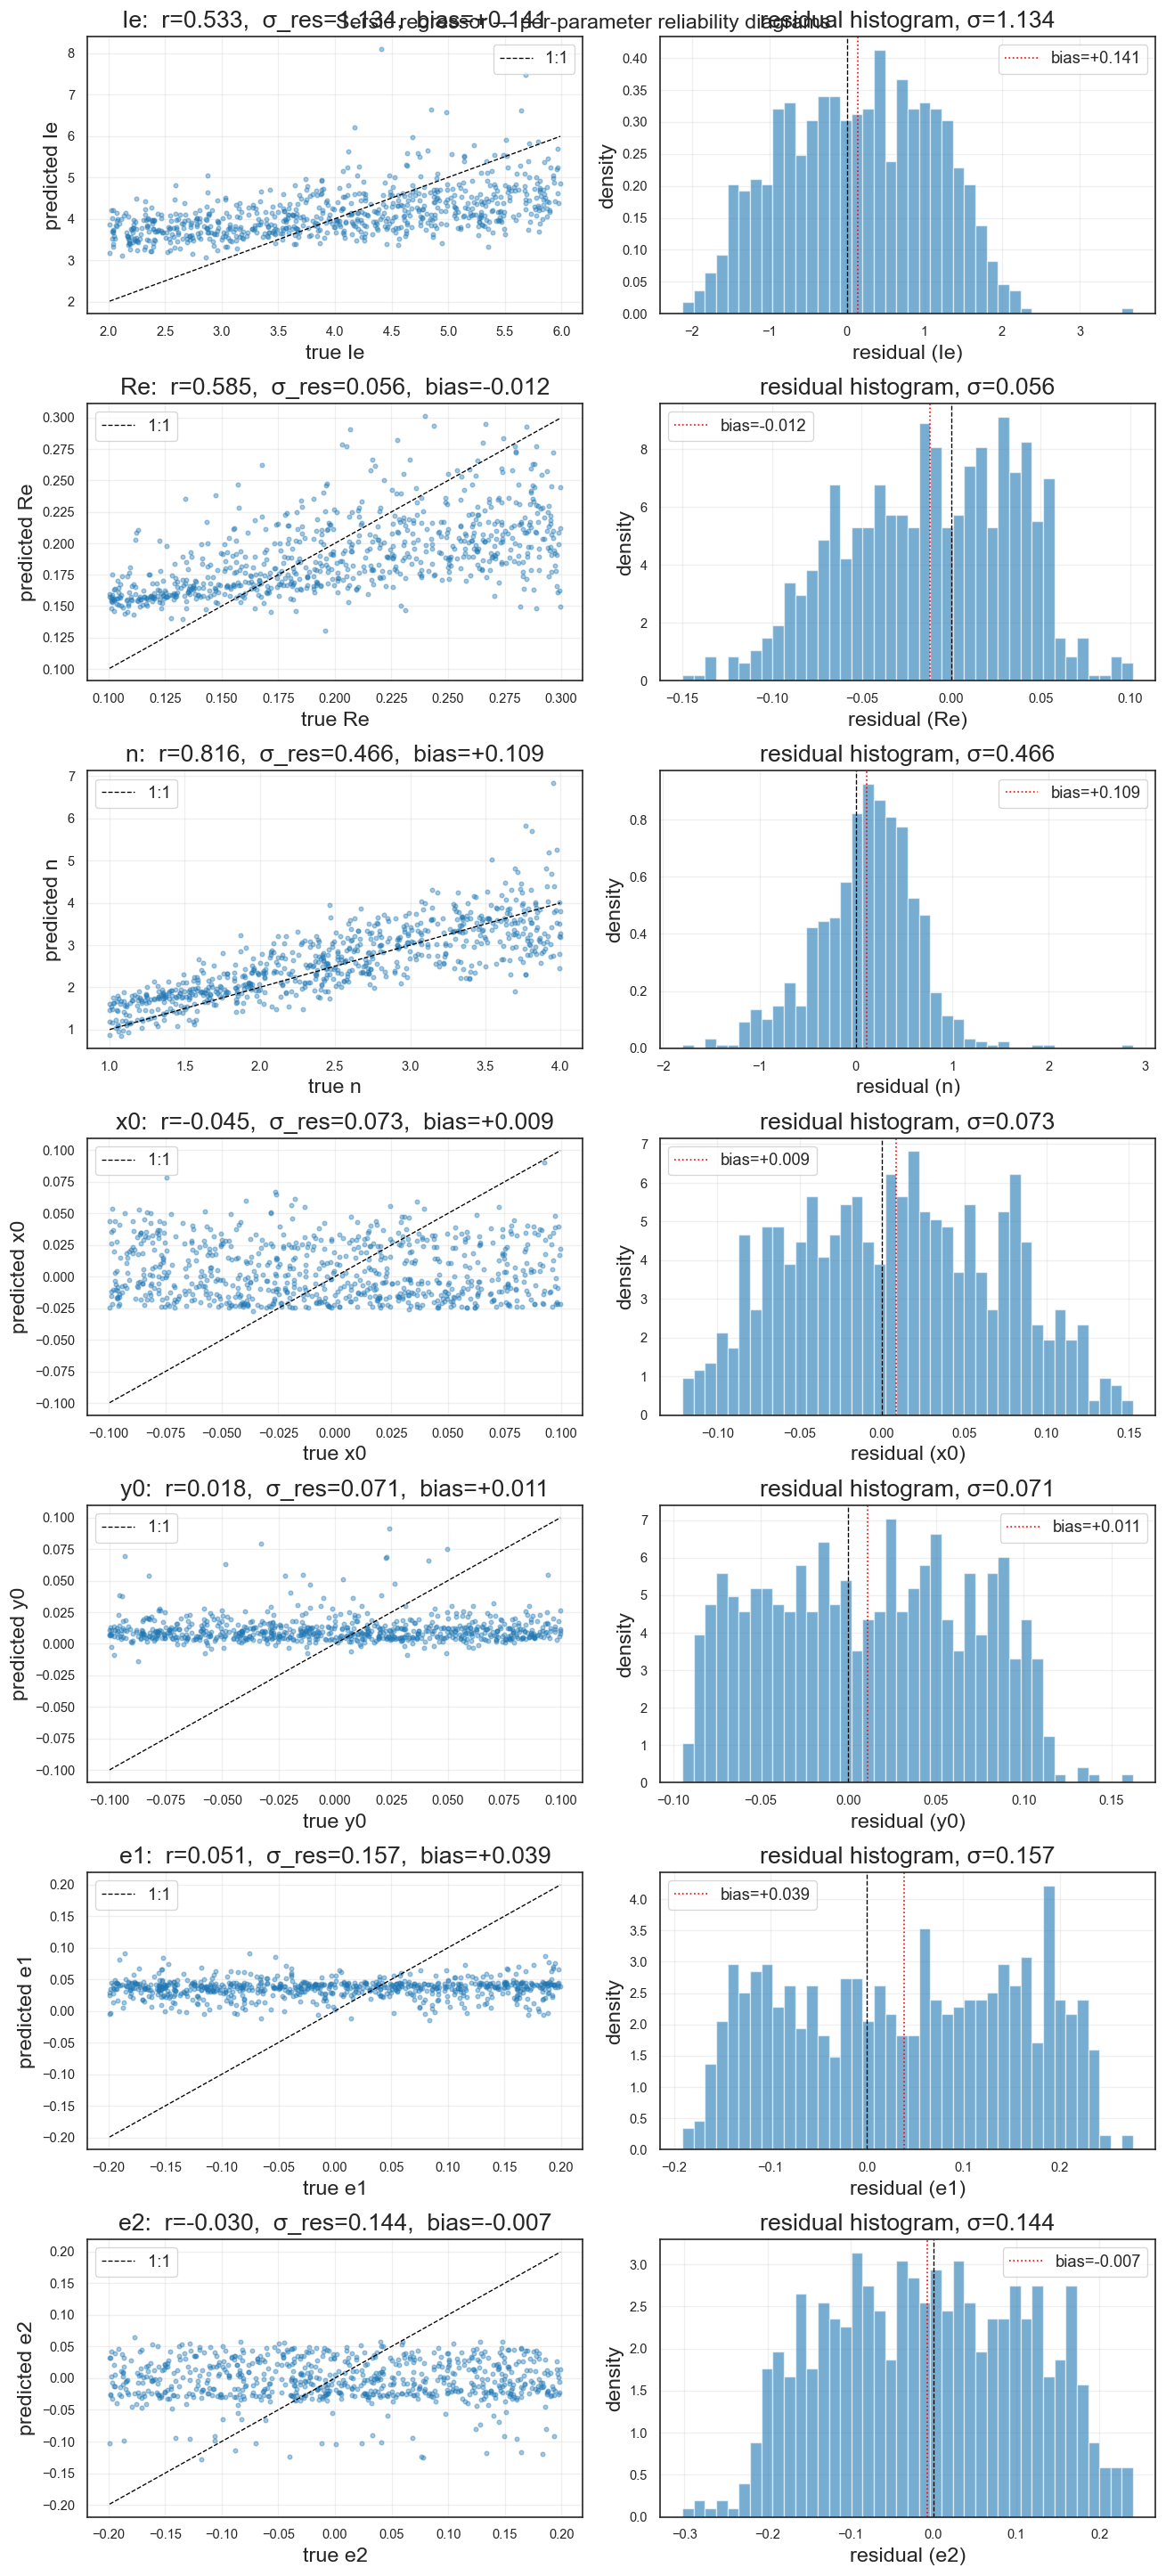

=== Pearson correlation ===
  r(Ie) :      +0.5334
  r(Re) :      +0.5848
  r(n)  :      +0.8164
  r(x0) :       -0.045
  r(y0) :     +0.01803
  r(e1) :     +0.05073
  r(e2) :     -0.02977

=== Robust scatter (MAD-based) ===
  sigma(Ie) :       +1.134
  sigma(Re) :     +0.05565
  sigma(n)  :      +0.4662
  sigma(x0) :     +0.07284
  sigma(y0) :     +0.07125
  sigma(e1) :      +0.1572
  sigma(e2) :      +0.1445

=== Systematic bias ===
  bias(Ie) :      +0.1412
  bias(Re) :     -0.01169
  bias(n)  :      +0.1091
  bias(x0) :    +0.008602
  bias(y0) :     +0.01111
  bias(e1) :     +0.03901
  bias(e2) :    -0.007297


In [4]:
from lensing.ml.datasets import PARAM_KEYS
test_loader = DataLoader(test_ds, batch_size=128)
preds, truths = [], []
model.eval()
with torch.no_grad():
    for x, y in test_loader:
        preds.append(model(x.to(device)).cpu().numpy())
        truths.append(y.numpy())
preds = np.vstack(preds); truths = np.vstack(truths)

fig, _, summary = gl.viz.diagnostics.plot_regression_diagnostics(
    truths, preds, param_names=PARAM_KEYS,
    title='Sersic regressor — per-parameter reliability diagrams',
)
plt.show()

# Compact tabular printout of the three indicators per parameter.
print(gl.viz.diagnostics.format_summary(
    {f'r({k})':     summary[k]['r']     for k in PARAM_KEYS},
    'Pearson correlation'))
print()
print(gl.viz.diagnostics.format_summary(
    {f'sigma({k})': summary[k]['sigma'] for k in PARAM_KEYS},
    'Robust scatter (MAD-based)'))
print()
print(gl.viz.diagnostics.format_summary(
    {f'bias({k})':  summary[k]['bias']  for k in PARAM_KEYS},
    'Systematic bias'))


**Interpreting the metrics**:

* σ_residual ≪ *prior width* ⇒ the network has actually
  learned something; σ_residual ≈ *prior width* would mean
  the regressor essentially predicts the prior mean.
* |bias| ≲ σ_residual / √N is consistent with no systematic
  offset; a larger bias suggests data leakage or insufficient
  training.
* Pearson r > 0.9 indicates a usefully tight correlation;
  the centroids `(x0, y0)` and the brightness `Ie` typically
  reach r ≳ 0.95 for our default network, while the more
  shape-dependent `(n, e1, e2)` lag behind.

## 3. Comparison with classical Adam fit

On the same 100-sample test subset, we run the classical per-image Adam fit and compare the cumulative wall time and the per-parameter accuracy. The DNN's edge is **inference speed**: ~10–100× faster per image, at the cost of a small (but measurable) increase in scatter.

In [5]:
import time

n_compare = 50
xy = gl.data.coordinate_grid(npix=test_ds.meta['npix'],
                              deltapix=test_ds.meta['deltapix'])
sigma_n = float(test_ds.meta['sigma'])

# DNN inference (one batch). Move both the input and the
# output across the device boundary because the trained
# `model` lives on `device` and downstream NumPy code
# expects CPU arrays.
t0 = time.perf_counter()
with torch.no_grad():
    imgs = torch.stack([test_ds[i][0] for i in range(n_compare)]).to(device)
    pred_dnn = model(imgs).cpu().numpy()
t_dnn = time.perf_counter() - t0

# Adam fit (one image at a time) — short budget
t0 = time.perf_counter()
pred_adam = []
for i in range(n_compare):
    img = test_ds[i][0][0]
    g = gl.light.Sersic(Ie=2., Re=1., n=2.5, x0=0., y0=0., e1=0., e2=0.)
    gl.inference.fit(
        g, xy, img,
        gl.inference.ReducedChiSquared(sigma=sigma_n, n_params=7),
        lr=0.05, epochs=200, grad_clip=10.0,
    )
    pred_adam.append([float(getattr(g, k)) for k in PARAM_KEYS])
pred_adam = np.array(pred_adam)
t_adam = time.perf_counter() - t0

true = np.stack([test_ds[i][1].numpy() for i in range(n_compare)])
err_dnn  = (pred_dnn  - true).std(axis=0)
err_adam = (pred_adam - true).std(axis=0)

print(f'DNN  : {t_dnn*1000:7.1f} ms total ({1000*t_dnn/n_compare:.2f} ms/sample)')
print(f'Adam : {t_adam*1000:7.1f} ms total ({1000*t_adam/n_compare:.2f} ms/sample)')
print(f'Speed-up: {t_adam/t_dnn:.0f}×')
print()
print('per-parameter std-of-residual (lower is better):')
for i, k in enumerate(PARAM_KEYS):
    print(f'  {k:<3s}: DNN = {err_dnn[i]:.3f}    Adam = {err_adam[i]:.3f}')


DNN  :   561.1 ms total (11.22 ms/sample)
Adam :  8357.7 ms total (167.15 ms/sample)
Speed-up: 15×

per-parameter std-of-residual (lower is better):
  Ie : DNN = 1.057    Adam = 1.605
  Re : DNN = 0.046    Adam = 1.761
  n  : DNN = 0.511    Adam = 0.888
  x0 : DNN = 0.068    Adam = 0.444
  y0 : DNN = 0.056    Adam = 0.433
  e1 : DNN = 0.123    Adam = 0.415
  e2 : DNN = 0.113    Adam = 0.397
